# char_03 — Burned versus unburned, and where Addis falls between them

## Purpose

`char_02` placed Addis at the 400 °C tier of the charcoal library, but with two large
qualifiers: the match quality (r ≈ 0.78) sits well below what charcoal-to-charcoal
matching achieves, and 400 °C is exactly where the aromatization signature turns over
and stops discriminating.

This notebook asks the cruder question, which is better posed:

> Does an Addis filter look more like **burned** material or **unburned** biomass?

## Where the unburned material comes from

Only the two McCall collections include the **unpyrolyzed feedstock** — raw material at
0 °C, before any heating. That is **24 spectra**: six feedstocks × 3 replicates in the
multi-feedstock workbook, plus 6 replicates of raw barley straw. Every other collection
in the archive starts at 200 °C.

This is the notebook's central limitation and it is not a small one. The entire
unburned reference is 24 spectra from one laboratory on one instrument. Everything
below is therefore built as a **paired** comparison inside McCall — where burned and
unburned share feedstock, instrument and preparation — and validated by
leave-one-feedstock-out cross-validation before it is pointed at Addis.

## Takeaways

See the end of the notebook.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

sys.path.insert(0, str(Path("scripts").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from charcoal_spectra import (
    load_all, snv, resample, detrend, prepare, prepare_shape, shape_norm,
    ramp_score, band_area, BANDS, ADDIS_USABLE,
)
from etad_spectra import load_etad

PLOT_DIR = Path("output/plots/char03")
TABLE_DIR = Path("output/tables/char03")
for d in (PLOT_DIR, TABLE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260722
rng = np.random.default_rng(RANDOM_SEED)

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#7a7972", "axes.labelcolor": "#0b0b0b",
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.axisbelow": True, "xtick.color": "#52514e", "ytick.color": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "legend.frameon": False,
    "figure.dpi": 110,
})

SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#a3a29b"
ADDIS_COLOR = "#4a3aa7"
UNBURNED_C, LOWCHAR_C, HIGHCHAR_C = "#1baf7a", "#eda100", "#e34948"

# Preprocessing provenance, stamped on every figure containing Addis (see char_02 §0).
ADDIS_PREP = ("Addis (ETAD): AIRSpec-baselined (APRLssb segmented spline, df1=6) "
              "→ linear detrend → SNV   ·   McCall: as published → detrend → SNV")


def stamp(fig, text=ADDIS_PREP):
    fig.text(0.5, -0.015, text, ha="center", va="top", fontsize=8, color=INK2)

SEASON_COLORS = {
    "Dry Season": "#E67E22",
    "Belg Rainy Season": "#27AE60",
    "Kiremt Rainy Season": "#3498DB",
}
SEASON_MAP = {
    "Dry (Oct-Feb)": "Dry Season",
    "Belg (Mar-May)": "Belg Rainy Season",
    "Kiremt (Jun-Sep)": "Kiremt Rainy Season",
}

# Two grids, deliberately. The wide one uses everything McCall measured and shows the
# burned/unburned contrast in full, including the C-O fingerprint. The narrow one is the
# only region where Addis can be compared at all.
GRID_WIDE = np.arange(650.0, 3500.0 + 1e-9, 2.0)
GRID_ADDIS = np.arange(1430.0, 3500.0 + 1e-9, 2.0)
print(f"McCall-only window : {GRID_WIDE.min():.0f}–{GRID_WIDE.max():.0f} cm⁻¹")
print(f"Addis-comparable   : {GRID_ADDIS.min():.0f}–{GRID_ADDIS.max():.0f} cm⁻¹")

McCall-only window : 650–3500 cm⁻¹
Addis-comparable   : 1430–3500 cm⁻¹


## Load: the McCall burned/unburned pair, everything else, and Addis

In [2]:
sets = load_all()
mccall = pd.concat(
    [sets["mccall_multi"].meta.assign(collection="McCall 6-feedstock"),
     sets["mccall_barley"].meta.assign(collection="McCall barley")],
    ignore_index=True,
)
X_mc_wide = np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID_WIDE),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID_WIDE),
])
X_mc_addis = np.vstack([
    resample(sets["mccall_multi"].X, sets["mccall_multi"].wn, GRID_ADDIS),
    resample(sets["mccall_barley"].X, sets["mccall_barley"].wn, GRID_ADDIS),
])
# Companion (unit-area) forms are kept alongside the SNV forms so the overlay
# figures can also be shown in absorbance-like units. Statistics stay on SNV.
X_mc_wide_s = shape_norm(detrend(X_mc_wide, GRID_WIDE), GRID_WIDE)
X_mc_addis_s = shape_norm(detrend(X_mc_addis, GRID_ADDIS), GRID_ADDIS)
X_mc_wide = snv(detrend(X_mc_wide, GRID_WIDE))
X_mc_addis = snv(detrend(X_mc_addis, GRID_ADDIS))

mccall["burned"] = mccall["temp_c"] > 0
mccall["class"] = np.where(
    mccall["temp_c"] == 0, "unburned feedstock",
    np.where(mccall["temp_c"] <= 350, "low-temp char (150–350 °C)",
             "high-temp char (400–700 °C)"))

print("McCall burned/unburned inventory:")
display(mccall.groupby(["class", "collection"]).size().rename("spectra").to_frame())
print(f"\nunburned total: {(~mccall['burned']).sum()}   burned total: {mccall['burned'].sum()}")
print("unburned feedstocks:", sorted(mccall.loc[~mccall["burned"], "species"].unique()))

# Addis
# AIRSpec-baselined + detrended — see char_02 section 0. Offset correction alone leaves a
# featureless sloping background (ramp score +0.995) that would make every band value
# below a position on that slope rather than an absorption measurement.
etad_meta, X_etad_base, wn_etad_b = load_etad(baselined=True)
etad_meta = etad_meta.copy()
etad_meta["season_label"] = etad_meta["season"].map(SEASON_MAP)
X_addis = prepare(X_etad_base, wn_etad_b, GRID_ADDIS)
X_addis_shape = prepare_shape(X_etad_base, wn_etad_b, GRID_ADDIS)
print(f"\nAddis filters: {X_addis.shape[0]} (AIRSpec-baselined + detrended)")
print(f"ramp score — Addis {ramp_score(X_addis, GRID_ADDIS):+.3f}, "
      f"McCall {ramp_score(X_mc_addis, GRID_ADDIS):+.3f}  (0 = no residual slope)")

# Everything else in the archive, on the Addis-comparable grid, as context
other = {k: snv(detrend(resample(s.X, s.wn, GRID_ADDIS), GRID_ADDIS))
         for k, s in sets.items() if k not in ("mccall_multi", "mccall_barley")}

McCall burned/unburned inventory:


spectra
class                       collection                 
high-temp char (400–700 °C) McCall 6-feedstock       72
                            McCall barley            42
low-temp char (150–350 °C)  McCall 6-feedstock       72
                            McCall barley            30
unburned feedstock          McCall 6-feedstock       18
                            McCall barley             6


unburned total: 24   burned total: 216
unburned feedstocks: ['barley straw', 'chestnut wood', 'eucalyptus bark', 'miscanthus grass', 'pine bark', 'rice husk']
Filter dataset loaded: 44493 measurements
Sites: ['CHTS' 'ETAD' 'INDH' 'USPA']
Date range: 2013-06-28 to 2024-12-08



Addis filters: 239 (AIRSpec-baselined + detrended)
ramp score — Addis -0.000, McCall +0.000  (0 = no residual slope)


## 1. What burning actually does to a spectrum

The full McCall window, so the C–O fingerprint region is visible. Three classes: raw
feedstock, lightly charred, heavily charred. This is the reference contrast that the
rest of the notebook leans on.

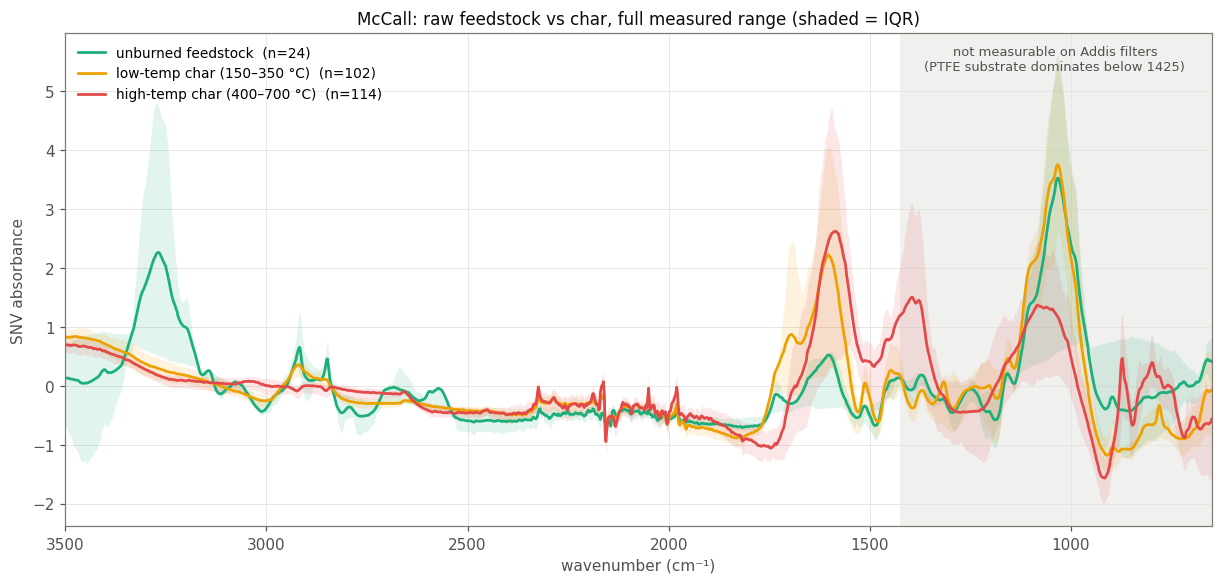

In [3]:
CLASS_ORDER = ["unburned feedstock", "low-temp char (150–350 °C)",
               "high-temp char (400–700 °C)"]
CLASS_COLORS = dict(zip(CLASS_ORDER, [UNBURNED_C, LOWCHAR_C, HIGHCHAR_C]))

fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
for cls in CLASS_ORDER:
    m = (mccall["class"] == cls).to_numpy()
    mu = X_mc_wide[m].mean(0)
    q1, q3 = np.percentile(X_mc_wide[m], [25, 75], axis=0)
    ax.plot(GRID_WIDE, mu, color=CLASS_COLORS[cls], lw=1.8, label=f"{cls}  (n={m.sum()})")
    ax.fill_between(GRID_WIDE, q1, q3, color=CLASS_COLORS[cls], alpha=0.13, lw=0)
ax.axvspan(GRID_WIDE.min(), ADDIS_USABLE[0], color=MUTED, alpha=0.16, lw=0, zorder=0)
ax.annotate("not measurable on Addis filters\n(PTFE substrate dominates below 1425)",
            xy=(1040, ax.get_ylim()[1]), xytext=(0, -8), textcoords="offset points",
            ha="center", va="top", fontsize=8.5, color=INK2)
ax.set_xlim(GRID_WIDE.max(), GRID_WIDE.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("McCall: raw feedstock vs char, full measured range (shaded = IQR)",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
fig.savefig(PLOT_DIR / "01a_classes_full_range.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — same classes with unit-area scaling instead of SNV
(`shape_norm`), so the curves read as band intensity. Statistics are unaffected.

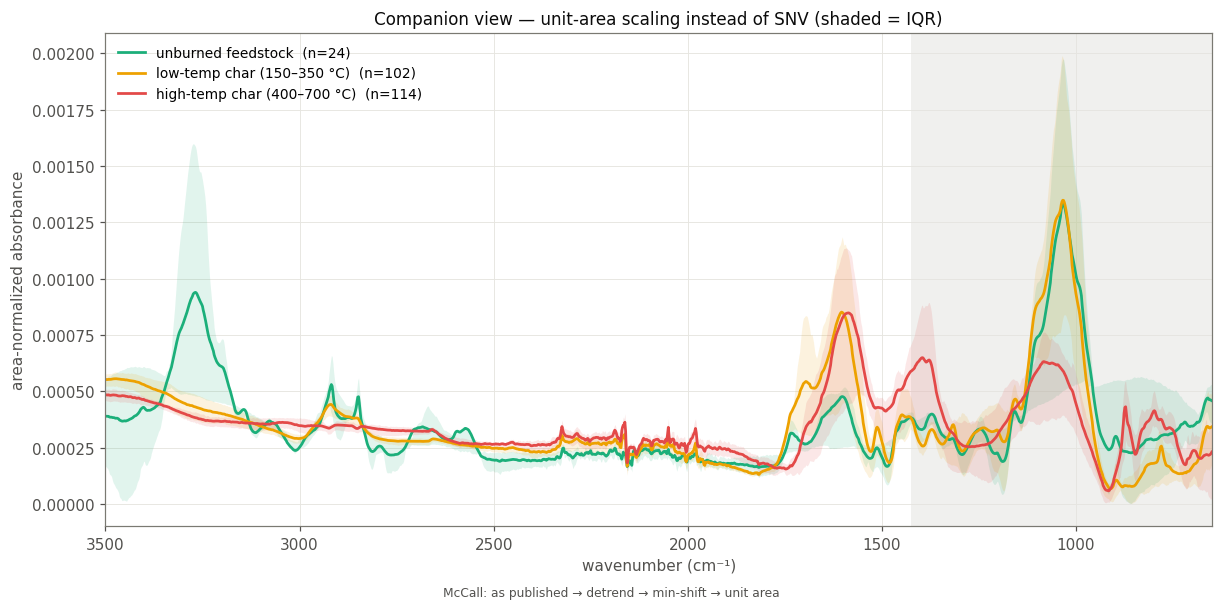

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
for cls in CLASS_ORDER:
    m = (mccall["class"] == cls).to_numpy()
    mu = X_mc_wide_s[m].mean(0)
    q1, q3 = np.percentile(X_mc_wide_s[m], [25, 75], axis=0)
    ax.plot(GRID_WIDE, mu, color=CLASS_COLORS[cls], lw=1.8, label=f"{cls}  (n={m.sum()})")
    ax.fill_between(GRID_WIDE, q1, q3, color=CLASS_COLORS[cls], alpha=0.13, lw=0)
ax.axvspan(GRID_WIDE.min(), ADDIS_USABLE[0], color=MUTED, alpha=0.16, lw=0, zorder=0)
ax.set_xlim(GRID_WIDE.max(), GRID_WIDE.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV (shaded = IQR)",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig, "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "01c_classes_full_range_shape.png", dpi=160, bbox_inches="tight")
plt.show()

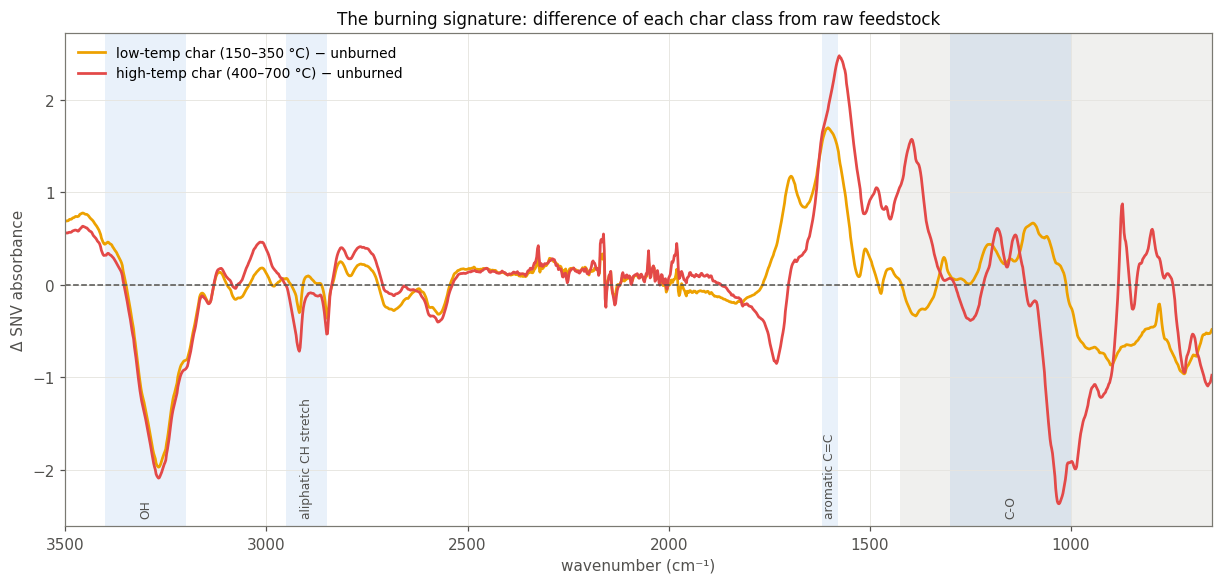

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.2), constrained_layout=True)
unb = X_mc_wide[(mccall["class"] == "unburned feedstock").to_numpy()].mean(0)
for cls in CLASS_ORDER[1:]:
    m = (mccall["class"] == cls).to_numpy()
    ax.plot(GRID_WIDE, X_mc_wide[m].mean(0) - unb, color=CLASS_COLORS[cls], lw=1.8,
            label=f"{cls} − unburned")
ax.axhline(0, color=INK2, lw=1, ls="--")
ax.axvspan(GRID_WIDE.min(), ADDIS_USABLE[0], color=MUTED, alpha=0.16, lw=0, zorder=0)
for name in ["OH / NH stretch", "aliphatic CH stretch", "aromatic C=C", "C-O / C-O-C"]:
    lo, hi = BANDS[name]
    ax.axvspan(lo, hi, color=SERIES[0], alpha=0.10, lw=0, zorder=0)
    ax.annotate(name.split(" /")[0], xy=((lo + hi) / 2, ax.get_ylim()[0]),
                xytext=(0, 5), textcoords="offset points", ha="center", va="bottom",
                fontsize=8, color=INK2, rotation=90)
ax.set_xlim(GRID_WIDE.max(), GRID_WIDE.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("Δ SNV absorbance", color=INK2)
ax.set_title("The burning signature: difference of each char class from raw feedstock",
             color=INK)
ax.legend(fontsize=9, loc="upper left")
fig.savefig(PLOT_DIR / "01b_burning_difference.png", dpi=160, bbox_inches="tight")
plt.show()

## 2. The same contrast, restricted to what Addis can be compared on

Everything below 1430 cm⁻¹ is now gone — including the C–O fingerprint that carries
much of the contrast above. The question is whether enough separation survives.

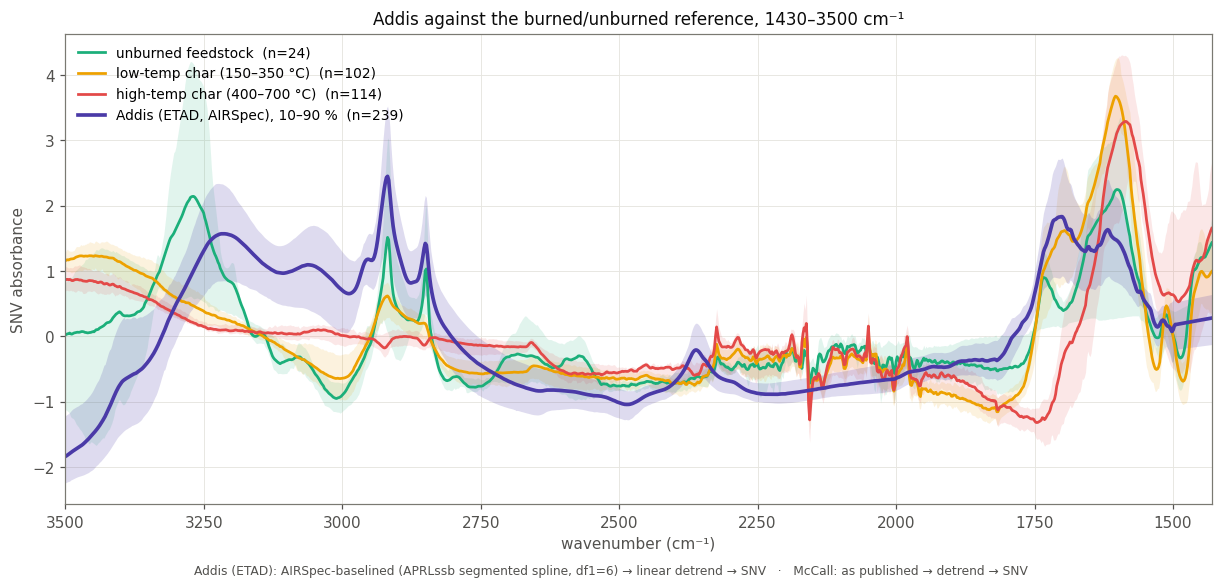

In [6]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for cls in CLASS_ORDER:
    m = (mccall["class"] == cls).to_numpy()
    mu = X_mc_addis[m].mean(0)
    q1, q3 = np.percentile(X_mc_addis[m], [25, 75], axis=0)
    ax.plot(GRID_ADDIS, mu, color=CLASS_COLORS[cls], lw=1.8, label=f"{cls}  (n={m.sum()})")
    ax.fill_between(GRID_ADDIS, q1, q3, color=CLASS_COLORS[cls], alpha=0.13, lw=0)
a_lo, a_hi = np.percentile(X_addis, [10, 90], axis=0)
ax.fill_between(GRID_ADDIS, a_lo, a_hi, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID_ADDIS, X_addis.mean(0), color=ADDIS_COLOR, lw=2.4,
        label=f"Addis (ETAD, AIRSpec), 10–90 %  (n={X_addis.shape[0]})")
ax.set_xlim(GRID_ADDIS.max(), GRID_ADDIS.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("SNV absorbance", color=INK2)
ax.set_title("Addis against the burned/unburned reference, 1430–3500 cm⁻¹", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig)
fig.savefig(PLOT_DIR / "02_addis_vs_classes.png", dpi=160, bbox_inches="tight")
plt.show()

**Companion view** — the same comparison with unit-area scaling instead of SNV, the
Addis side AIRSpec-baselined as everywhere in this folder.

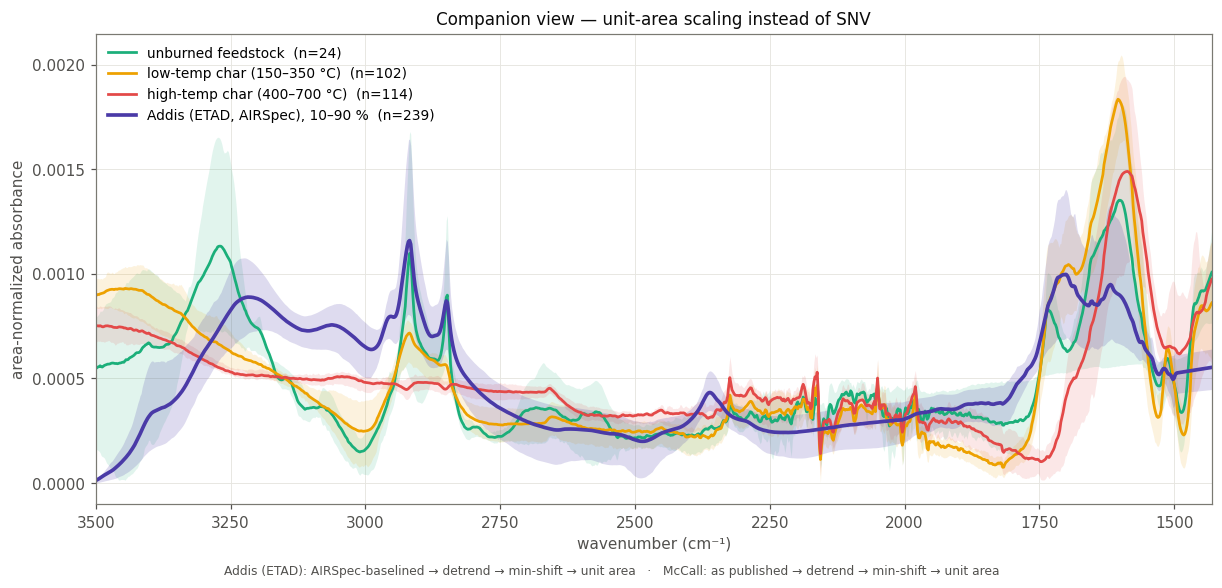

In [7]:
fig, ax = plt.subplots(figsize=(11, 5), constrained_layout=True)
for cls in CLASS_ORDER:
    m = (mccall["class"] == cls).to_numpy()
    mu = X_mc_addis_s[m].mean(0)
    q1, q3 = np.percentile(X_mc_addis_s[m], [25, 75], axis=0)
    ax.plot(GRID_ADDIS, mu, color=CLASS_COLORS[cls], lw=1.8, label=f"{cls}  (n={m.sum()})")
    ax.fill_between(GRID_ADDIS, q1, q3, color=CLASS_COLORS[cls], alpha=0.13, lw=0)
a_lo_s, a_hi_s = np.percentile(X_addis_shape, [10, 90], axis=0)
ax.fill_between(GRID_ADDIS, a_lo_s, a_hi_s, color=ADDIS_COLOR, alpha=0.18, lw=0)
ax.plot(GRID_ADDIS, X_addis_shape.mean(0), color=ADDIS_COLOR, lw=2.4,
        label=f"Addis (ETAD, AIRSpec), 10–90 %  (n={X_addis_shape.shape[0]})")
ax.set_xlim(GRID_ADDIS.max(), GRID_ADDIS.min())
ax.set_xlabel("wavenumber (cm⁻¹)", color=INK2)
ax.set_ylabel("area-normalized absorbance", color=INK2)
ax.set_title("Companion view — unit-area scaling instead of SNV", color=INK)
ax.legend(fontsize=9, loc="upper left")
stamp(fig, "Addis (ETAD): AIRSpec-baselined → detrend → min-shift → unit area   ·   "
           "McCall: as published → detrend → min-shift → unit area")
fig.savefig(PLOT_DIR / "02b_addis_vs_classes_shape.png", dpi=160, bbox_inches="tight")
plt.show()

## 3. A burned/unburned classifier, honestly cross-validated

Logistic regression on 8 principal components of the McCall spectra, class-weighted to
handle the 24-vs-216 imbalance. Validated **leave-one-feedstock-out**: the model never
sees the held-out feedstock's raw material *or* its chars, so it cannot pass by
memorizing a feedstock. Only then is it pointed at Addis.

In [8]:
groups = mccall["species"].to_numpy()
y = mccall["burned"].to_numpy().astype(int)


def make_model():
    return make_pipeline(
        PCA(n_components=8, random_state=RANDOM_SEED),
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=5000,
                           random_state=RANDOM_SEED),
    )


cv_rows = []
for feedstock in np.unique(groups):
    test = groups == feedstock
    model = make_model().fit(X_mc_addis[~test], y[~test])
    prob = model.predict_proba(X_mc_addis[test])[:, 1]
    cv_rows.append(pd.DataFrame({
        "feedstock": feedstock, "true_burned": y[test], "p_burned": prob,
        "temp_c": mccall.loc[test, "temp_c"].to_numpy(),
    }))
cv = pd.concat(cv_rows, ignore_index=True)
cv["correct"] = (cv["p_burned"] > 0.5).astype(int) == cv["true_burned"]

print("leave-one-feedstock-out performance (Addis-comparable window):")
print(f"  overall accuracy      : {cv['correct'].mean():.1%}")
print(f"  unburned recall       : {cv.loc[cv.true_burned == 0, 'correct'].mean():.1%} "
      f"(n={int((cv.true_burned == 0).sum())})")
print(f"  burned recall         : {cv.loc[cv.true_burned == 1, 'correct'].mean():.1%} "
      f"(n={int((cv.true_burned == 1).sum())})")
display(cv.groupby("feedstock")[["correct"]].mean().round(3).rename(
    columns={"correct": "accuracy"}))
cv.to_csv(TABLE_DIR / "loo_feedstock_cv.csv", index=False)

leave-one-feedstock-out performance (Addis-comparable window):
  overall accuracy      : 90.0%
  unburned recall       : 41.7% (n=24)
  burned recall         : 95.4% (n=216)


,accuracy
feedstock,
barley straw,0.876
chestnut wood,1.000
eucalyptus bark,0.889
miscanthus grass,0.889
pine bark,0.889
rice husk,0.926


In [9]:
# Final model on all McCall, applied to Addis and to the rest of the archive.
final = make_model().fit(X_mc_addis, y)
p_addis = final.predict_proba(X_addis)[:, 1]
p_other = {k: final.predict_proba(v)[:, 1] for k, v in other.items()}

print(f"\nAddis: P(burned) median {np.median(p_addis):.3f}  "
      f"[{np.percentile(p_addis, 10):.3f}–{np.percentile(p_addis, 90):.3f}]")
print(f"  classified 'burned': {(p_addis > 0.5).mean():.0%} of {len(p_addis)} filters")
print("\nsanity check — the rest of the archive is entirely ≥200 °C, so it should all "
      "read as burned:")
for k, v in p_other.items():
    print(f"  {sets[k].short:20s} median P(burned) = {np.median(v):.3f}  "
          f"→ {(v > 0.5).mean():.0%} burned")


Addis: P(burned) median 0.040  [0.009–0.214]
  classified 'burned': 1% of 239 filters

sanity check — the rest of the archive is entirely ≥200 °C, so it should all read as burned:
  Minatre ref          median P(burned) = 0.997  → 69% burned
  Minatre burns        median P(burned) = 0.999  → 100% burned
  Maezumi              median P(burned) = 0.999  → 94% burned
  Gosling              median P(burned) = 0.999  → 94% burned


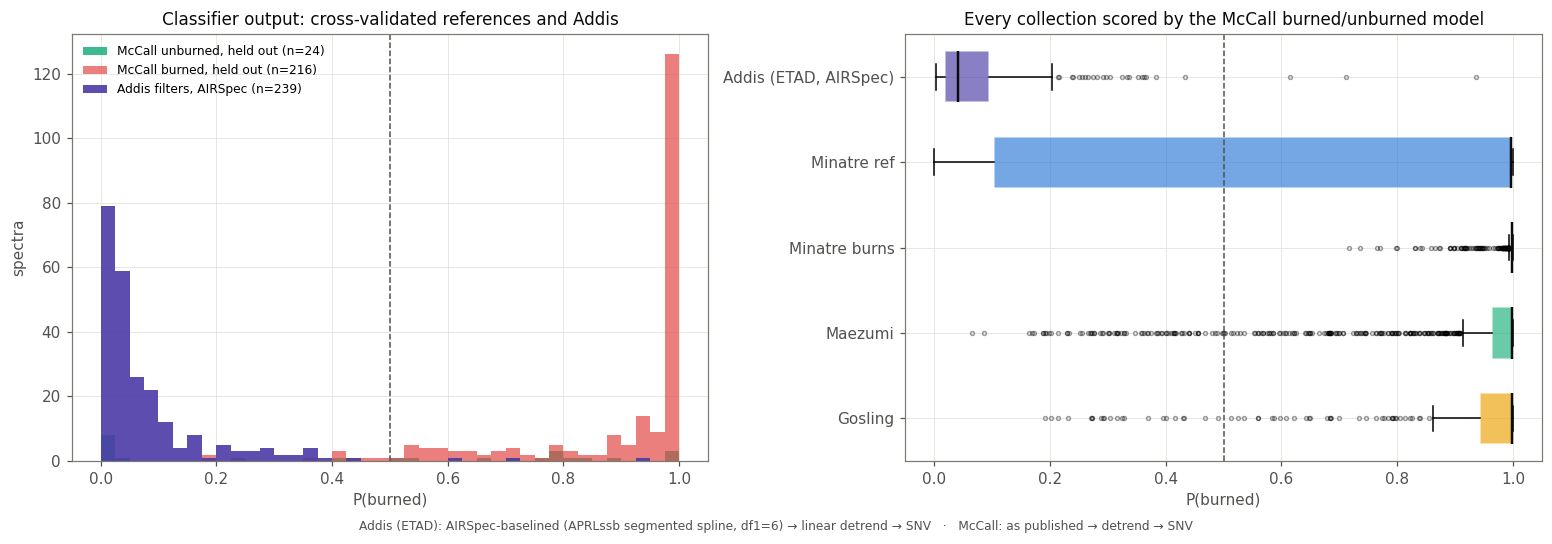

,count,mean,std,min,25%,50%,75%,max
season,,,,,,,,
Belg Rainy Season,61.0,0.089,0.134,0.005,0.024,0.042,0.077,0.712
Dry Season,105.0,0.047,0.106,0.002,0.011,0.023,0.044,0.936
Kiremt Rainy Season,73.0,0.125,0.097,0.012,0.048,0.098,0.170,0.366


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), constrained_layout=True)

ax = axes[0]
bins = np.linspace(0, 1, 41)
ax.hist(cv.loc[cv.true_burned == 0, "p_burned"], bins=bins, color=UNBURNED_C, alpha=0.85,
        label=f"McCall unburned, held out (n={int((cv.true_burned == 0).sum())})")
ax.hist(cv.loc[cv.true_burned == 1, "p_burned"], bins=bins, color=HIGHCHAR_C, alpha=0.7,
        label=f"McCall burned, held out (n={int((cv.true_burned == 1).sum())})")
ax.hist(p_addis, bins=bins, color=ADDIS_COLOR, alpha=0.9,
        label=f"Addis filters, AIRSpec (n={len(p_addis)})")
ax.axvline(0.5, color=INK2, lw=1, ls="--")
ax.set_xlabel("P(burned)", color=INK2)
ax.set_ylabel("spectra", color=INK2)
ax.set_title("Classifier output: cross-validated references and Addis", color=INK)
ax.legend(fontsize=8)

ax = axes[1]
order = ["Addis (ETAD, AIRSpec)"] + [sets[k].short for k in p_other]
vals = [p_addis] + [p_other[k] for k in p_other]
cols = [ADDIS_COLOR] + [SERIES[i % len(SERIES)] for i in range(len(p_other))]
bp = ax.boxplot(vals, vert=False, tick_labels=order, patch_artist=True, widths=0.6,
                medianprops=dict(color=INK, lw=1.6), flierprops=dict(ms=2.5, alpha=0.4))
for patch, c in zip(bp["boxes"], cols):
    patch.set_facecolor(c); patch.set_alpha(0.65); patch.set_edgecolor("white")
ax.axvline(0.5, color=INK2, lw=1, ls="--")
ax.set_xlabel("P(burned)", color=INK2)
ax.set_title("Every collection scored by the McCall burned/unburned model", color=INK)
ax.invert_yaxis()

stamp(fig)
fig.savefig(PLOT_DIR / "03_classifier.png", dpi=160, bbox_inches="tight")
plt.show()

addis_scores = pd.DataFrame({
    "FilterId": etad_meta["ExternalFilterId"].to_numpy(),
    "season": etad_meta["season_label"].to_numpy(),
    "SamplingStartDate": etad_meta["SamplingStartDate"].to_numpy(),
    "p_burned": p_addis,
    "Fabs": etad_meta["Fabs"].to_numpy(),
    "EC_deployed_ugm3": etad_meta["EC_deployed_ugm3"].to_numpy(),
})
addis_scores.to_csv(TABLE_DIR / "addis_burned_scores.csv", index=False)
display(addis_scores.groupby("season")["p_burned"].describe().round(3))

## 4. Band-by-band: which way does Addis lean?

The classifier gives one number. This gives the anatomy behind it — for each diagnostic
band inside the comparison window, the unburned mean, the burned mean, and where Addis
sits relative to both.

,unburned mean,burned mean,Addis mean,Addis sd,"Addis position (0=unburned, 1=burned)"
OH / NH stretch,1.17,0.50,0.46,0.35,1.05
aromatic CH stretch,-0.50,-0.16,1.07,0.47,4.70
aliphatic CH stretch,0.50,0.12,1.37,0.48,-2.31
carbonyl C=O,0.60,-0.05,1.43,0.51,-1.28
aromatic C=C,2.05,3.19,1.42,0.47,-0.56


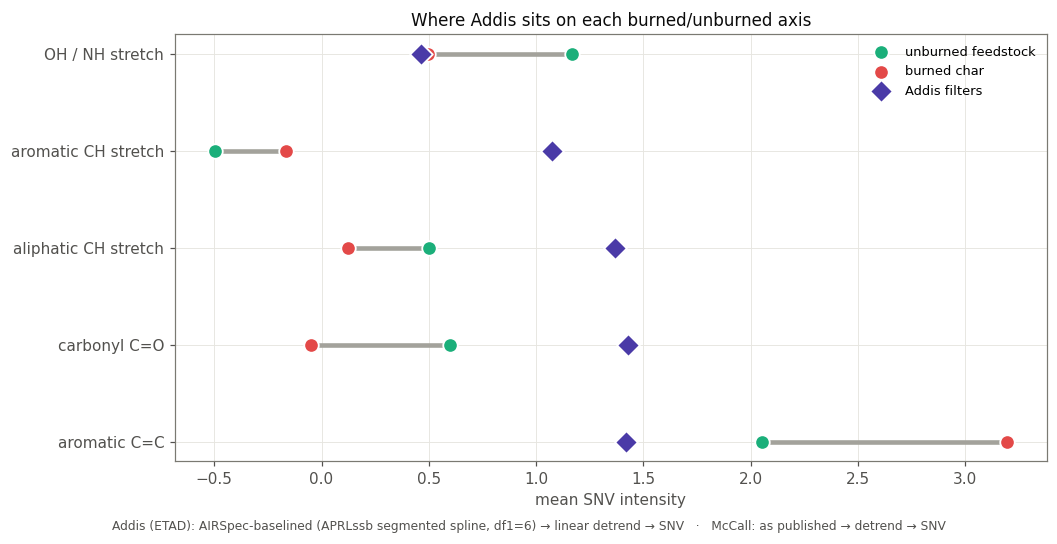

In [11]:
def bands_of(X, grid):
    return pd.DataFrame({name: band_area(X, grid, w) for name, w in BANDS.items()
                         if w[0] >= grid.min() and w[1] <= grid.max()})


ub = bands_of(X_mc_addis[(~mccall["burned"]).to_numpy()], GRID_ADDIS)
bn = bands_of(X_mc_addis[mccall["burned"].to_numpy()], GRID_ADDIS)
ad = bands_of(X_addis, GRID_ADDIS)

comparison = pd.DataFrame({
    "unburned mean": ub.mean(), "burned mean": bn.mean(), "Addis mean": ad.mean(),
    "Addis sd": ad.std(),
})
# Position of Addis on the unburned->burned axis: 0 = unburned, 1 = burned.
span = comparison["burned mean"] - comparison["unburned mean"]
comparison["Addis position (0=unburned, 1=burned)"] = (
    (comparison["Addis mean"] - comparison["unburned mean"]) / span)
display(comparison.round(2))
comparison.to_csv(TABLE_DIR / "band_positions.csv")

fig, ax = plt.subplots(figsize=(9.5, 4.6), constrained_layout=True)
ypos = np.arange(len(comparison))
ax.hlines(ypos, comparison["unburned mean"], comparison["burned mean"], color=MUTED, lw=3,
          zorder=1)
ax.scatter(comparison["unburned mean"], ypos, s=90, c=UNBURNED_C, edgecolor="white",
           linewidth=1.2, zorder=3, label="unburned feedstock")
ax.scatter(comparison["burned mean"], ypos, s=90, c=HIGHCHAR_C, edgecolor="white",
           linewidth=1.2, zorder=3, label="burned char")
ax.scatter(comparison["Addis mean"], ypos, s=110, c=ADDIS_COLOR, marker="D",
           edgecolor="white", linewidth=1.2, zorder=4, label="Addis filters")
ax.set_yticks(ypos); ax.set_yticklabels(comparison.index)
ax.set_xlabel("mean SNV intensity", color=INK2)
ax.set_title("Where Addis sits on each burned/unburned axis", color=INK)
ax.legend(fontsize=8.5, loc="best")
ax.invert_yaxis()
stamp(fig)
fig.savefig(PLOT_DIR / "04_band_positions.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Is the classifier interpolating or extrapolating?

The classifier returned P(burned) = 0.000 for all 239 filters. Before that is read as
"Addis looks like raw biomass", it has to be checked against the possibility that Addis
lies outside *both* training classes — in which case a two-class model still has to
return something, and will return it confidently.

The band-position column above is the direct test. A sample genuinely somewhere between
raw feedstock and char has a position in **[0, 1]** on each band axis. A position
outside that interval means the sample is not on the axis at all.

In [12]:
pos = comparison["Addis position (0=unburned, 1=burned)"]
off_axis = ((pos < 0) | (pos > 1))
print("Addis position on each burned→unburned band axis (0 = unburned, 1 = burned):")
for band, v in pos.items():
    flag = "OFF-AXIS" if off_axis[band] else "between the classes"
    print(f"  {band:24s} {v:7.2f}   {flag}")
print(f"\n{off_axis.sum()} of {len(pos)} band axes place Addis outside the "
      f"unburned–burned interval entirely.")

# Distance from the McCall training cloud, in the same 8-PC space the classifier uses.
pca_tr = PCA(n_components=8, random_state=RANDOM_SEED).fit(X_mc_addis)
S_tr, S_ad = pca_tr.transform(X_mc_addis), pca_tr.transform(X_addis)
inv = np.linalg.pinv(np.cov(S_tr.T))
ctr = S_tr.mean(0)
dist = lambda S: np.sqrt(np.einsum("ij,jk,ik->i", S - ctr, inv, S - ctr))
d_tr, d_ad = dist(S_tr), dist(S_ad)
print(f"\nMahalanobis distance from the McCall training cloud (8 PCs):")
print(f"  McCall training spectra : median {np.median(d_tr):.1f}, "
      f"99th pct {np.percentile(d_tr, 99):.1f}")
print(f"  Addis filters           : median {np.median(d_ad):.1f}")
print(f"  Addis beyond the training 99th percentile: "
      f"{(d_ad > np.percentile(d_tr, 99)).mean():.0%}")

Addis position on each burned→unburned band axis (0 = unburned, 1 = burned):
  OH / NH stretch             1.05   OFF-AXIS
  aromatic CH stretch         4.70   OFF-AXIS
  aliphatic CH stretch       -2.31   OFF-AXIS
  carbonyl C=O               -1.28   OFF-AXIS
  aromatic C=C               -0.56   OFF-AXIS

5 of 5 band axes place Addis outside the unburned–burned interval entirely.

Mahalanobis distance from the McCall training cloud (8 PCs):
  McCall training spectra : median 2.3, 99th pct 5.5
  Addis filters           : median 5.7
  Addis beyond the training 99th percentile: 59%


## Takeaways

- **Burning has a large, consistent spectral signature — but most of it lives where
  Addis cannot be measured.** Over McCall's full range the contrast between raw
  feedstock and char is dramatic: the O–H envelope and the C–O fingerprint collapse
  while aromatic C=C grows. Crop to the 1430–3500 cm⁻¹ window that PTFE-filter spectra
  permit and the most diagnostic part of that contrast — the entire C–O region — is
  gone.
- **What survives the crop is weak in exactly the direction that matters.** Cross-
  validated leave-one-feedstock-out accuracy is 90.0 % overall but **unburned recall is
  only 41.7 %** — worse than a coin flip on the class with 24 members. A model that
  cannot reliably recognize raw biomass in this window cannot be trusted to announce
  that something *is* raw biomass.
- **Addis is not on the burned–unburned axis at all, so P(burned) ≈ 0.04 is an
  extrapolation artifact and not a finding.** All five diagnostic band axes place Addis
  *outside* the interval spanned by the two classes — and not consistently at the
  unburned end either: it sits past the *burned* end on O–H and aromatic C–H, and past
  the *unburned* end on aliphatic C–H, carbonyl and aromatic C=C. **59 %** of filters
  lie beyond the 99th percentile of the training cloud. The classifier is being asked
  about material unlike anything it was shown, and a two-class model answers anyway.
- **The cross-collection sanity check independently limits how far this model travels.**
  Applied to the rest of the archive, which is entirely ≥ 200 °C and therefore all
  burned, it reads Minatre reference as only **69 %** burned. A model that loses a third
  of known char across a laboratory boundary is not a model to hang an ambient-aerosol
  conclusion on.
- **The defensible statement is negative and it is worth having.** Addis filter spectra
  in the measurable window resemble neither raw biomass nor charcoal from this archive;
  they are dominated by a broad O–H envelope and elevated aliphatic C–H that neither
  reference class shows. That is consistent with `char_02` and with an ambient mixture
  in which char is a minority component — but the archive as it stands cannot quantify
  that minority.

**What would change the answer:** unburned and low-temperature reference material
measured *on PTFE filters* rather than as bulk, so the comparison is not forced through
a window that discards the diagnostic region. Failing that, an Addis-side reference —
collocated filters of known biomass-burning origin — would let the mixture be
characterized directly rather than by analogy to pure materials.